# Results — comparative performance analysis

Base parameters throughout: $\lambda_1=0.3$, $\lambda_2=0.4$, $\mu=1.0$  ($\rho=0.7$, $\rho_1=0.3$, $\rho_2=0.4$).

Mechanism parameters are varied per section.

**Notation reminder:** $N_1, N_2, N$ count customers *waiting in the queues*; the customer in service is implicit.

In [1]:
%matplotlib inline
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from model_master import Params, solve_exact, diagnostics
from model_master_tilde import (
    solve_exact_tilde, convert_S_to_Stilde,
    marginals_tilde, diagnostics_tilde,
)

plt.rcParams.update({
    "font.family": "DejaVu Serif", "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
})

LAM1, LAM2, MU = 0.3, 0.4, 1.0
RHO = (LAM1 + LAM2) / MU

# Convenience: exact solve + diagnostics in one call
def solve_diag(p, n_max=60):
    r = solve_exact_tilde(p, n_max=n_max)
    d = diagnostics_tilde(p, r['pi_idle'], r['pi_tilde'])
    return r, d


## 1. Cross-model performance table

Mechanism parameters: $\gamma_1=0.5$ (Model B₂), $\theta_1=0.5$ (Model C₂).

In [2]:
from scipy.special import hyp1f1

def E_BC(lam1, mu, theta1):
    if theta1 == 0:
        return 1.0 / (mu - lam1)
    return hyp1f1(1, mu/theta1 + 1, lam1/theta1) / mu

models = [
    ('Model A',  Params(LAM1, LAM2, MU)),
    ('Model B₂ (γ₁=0.5)', Params(LAM1, LAM2, MU, gamma1=0.5)),
    ('Model C₂ (θ₁=0.5)', Params(LAM1, LAM2, MU, theta1=0.5)),
]

print(f"{'Model':<22} {'π₀':>8} {'P(busy)':>9} "
      f"{'E[N₁]':>8} {'E[N₂]':>8} {'E[N]':>8} {'throughput':>12}")
print('─' * 80)
for name, p in models:
    r, d = solve_diag(p)
    print(f"{name:<22} {r['pi_idle']:>8.4f} {d['P_busy']:>9.4f} "
          f"{d['E_n1']:>8.4f} {d['E_n2']:>8.4f} {d['E_n']:>8.4f} "
          f"{d['throughput']:>12.4f}")


Model                        π₀   P(busy)    E[N₁]    E[N₂]     E[N]   throughput
────────────────────────────────────────────────────────────────────────────────
Model A                  0.3000    0.7000   0.3000   1.3333   1.6333       0.7000
Model B₂ (γ₁=0.5)        0.3000    0.7000   0.1545   1.4788   1.6333       0.7000
Model C₂ (θ₁=0.5)        0.3696    0.6304   0.1392   0.6967   0.8358       0.6304


## 2. Priority benefit: $E[N_1]$ vs $E[N_2]$ across load $\rho$

We fix the load split $\lambda_1 / \lambda_2 = 3/4$ and vary $\mu$ to sweep $\rho \in [0.2, 0.92]$. Class-1 has priority; class-2 bears the congestion cost.

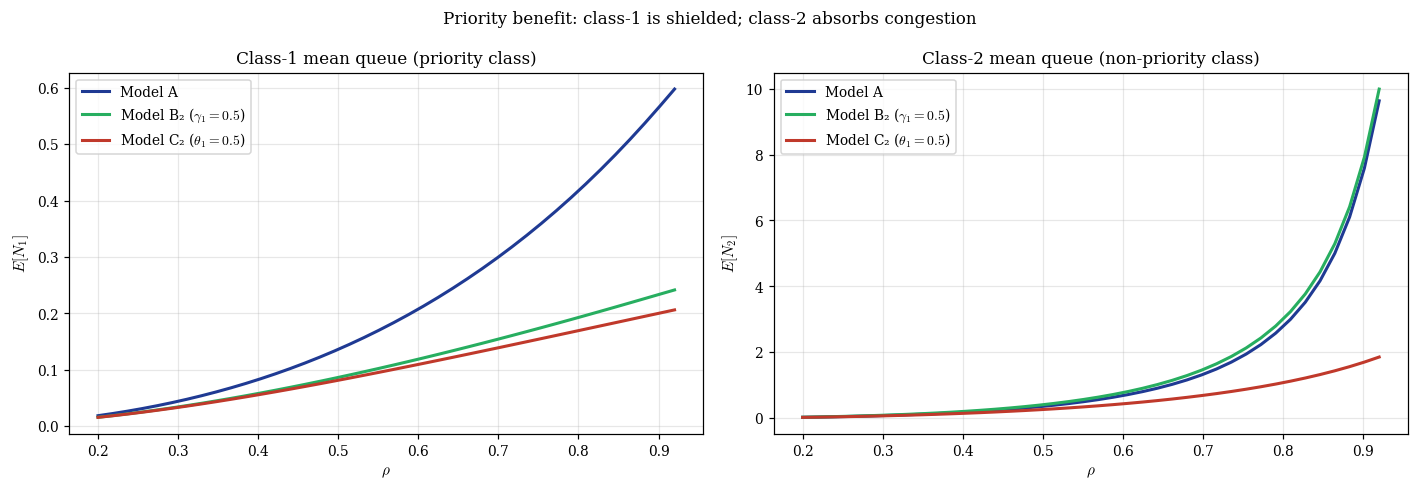

In [3]:
rho_vals = np.linspace(0.20, 0.92, 40)
En1_A, En2_A = [], []
En1_B2, En2_B2 = [], []
En1_C2, En2_C2 = [], []

for rho in rho_vals:
    mu = (LAM1 + LAM2) / rho
    pA  = Params(LAM1, LAM2, mu)
    pB2 = Params(LAM1, LAM2, mu, gamma1=0.5)
    pC2 = Params(LAM1, LAM2, mu, theta1=0.5)
    for p, en1_list, en2_list in [
        (pA, En1_A, En2_A), (pB2, En1_B2, En2_B2), (pC2, En1_C2, En2_C2)
    ]:
        r, d = solve_diag(p)
        en1_list.append(d['E_n1'])
        en2_list.append(d['E_n2'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
COLORS = {'A': '#1f3a93', 'B2': '#27ae60', 'C2': '#c0392b'}

for ax, (en1_vals, en2_vals, label, color) in zip(
    [axes[0], axes[0], axes[0]],
    [(En1_A, None, 'Model A', COLORS['A']),
     (En1_B2, None, r'Model B₂ ($\gamma_1=0.5$)', COLORS['B2']),
     (En1_C2, None, r'Model C₂ ($\theta_1=0.5$)', COLORS['C2'])]
):
    axes[0].plot(rho_vals, en1_vals, '-', color=color, lw=2, label=label)

for en2_vals, label, color in [
    (En2_A, 'Model A', COLORS['A']),
    (En2_B2, r'Model B₂ ($\gamma_1=0.5$)', COLORS['B2']),
    (En2_C2, r'Model C₂ ($\theta_1=0.5$)', COLORS['C2'])
]:
    axes[1].plot(rho_vals, en2_vals, '-', color=color, lw=2, label=label)

axes[0].set_xlabel(r'$\rho$'); axes[0].set_ylabel(r'$E[N_1]$')
axes[0].set_title('Class-1 mean queue (priority class)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_xlabel(r'$\rho$'); axes[1].set_ylabel(r'$E[N_2]$')
axes[1].set_title('Class-2 mean queue (non-priority class)')
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle(r'Priority benefit: class-1 is shielded; class-2 absorbs congestion', fontsize=11)
fig.tight_layout()


## 3. Effect of jockeying $\gamma_1$ — Model B₂

Model B₂ has one-way jockeying: class-1 customers may move to the class-2 queue at per-customer rate $\gamma_1$. Jockeying is queue-length-preserving ($N$ is unchanged), so it cannot improve throughput — but it redistributes $N_1$ and $N_2$.

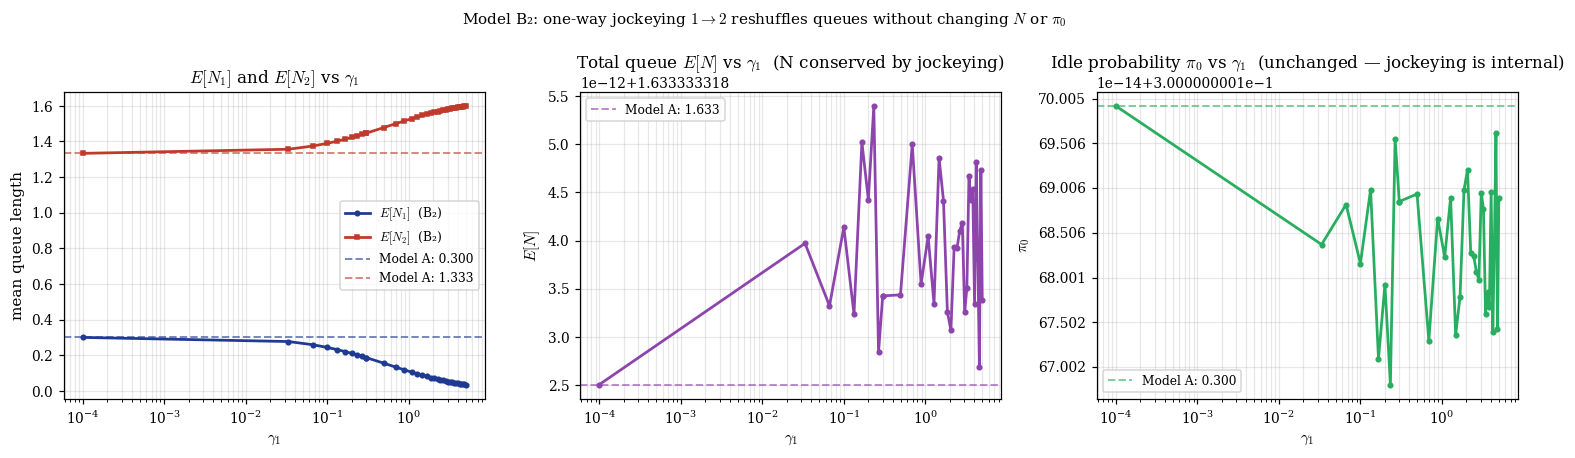

In [4]:
gamma1_vals = np.concatenate([np.linspace(0.0, 0.3, 10), np.linspace(0.3, 5.0, 25)])
metrics_B2 = {'pi0': [], 'E_n1': [], 'E_n2': [], 'E_n': [], 'throughput': []}

for g1 in gamma1_vals:
    p = Params(LAM1, LAM2, MU, gamma1=float(g1))
    r, d = solve_diag(p)
    metrics_B2['pi0'].append(r['pi_idle'])
    metrics_B2['E_n1'].append(d['E_n1'])
    metrics_B2['E_n2'].append(d['E_n2'])
    metrics_B2['E_n'].append(d['E_n'])
    metrics_B2['throughput'].append(d['throughput'])

# Model A reference
r_A, d_A = solve_diag(Params(LAM1, LAM2, MU))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

ax = axes[0]
ax.semilogx(gamma1_vals + 1e-4, metrics_B2['E_n1'], 'o-', color='#1f3a93', ms=3, lw=1.8,
            label=r'$E[N_1]$  (B₂)')
ax.semilogx(gamma1_vals + 1e-4, metrics_B2['E_n2'], 's-', color='#c0392b', ms=3, lw=1.8,
            label=r'$E[N_2]$  (B₂)')
ax.axhline(d_A['E_n1'], color='#1f3a93', ls='--', lw=1.3, alpha=0.6,
           label=f"Model A: {d_A['E_n1']:.3f}")
ax.axhline(d_A['E_n2'], color='#c0392b', ls='--', lw=1.3, alpha=0.6,
           label=f"Model A: {d_A['E_n2']:.3f}")
ax.set_xlabel(r'$\gamma_1$'); ax.set_ylabel('mean queue length')
ax.set_title(r'$E[N_1]$ and $E[N_2]$ vs $\gamma_1$')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')

ax = axes[1]
ax.semilogx(gamma1_vals + 1e-4, metrics_B2['E_n'], 'o-', color='#8e44ad', ms=3, lw=1.8)
ax.axhline(d_A['E_n'], color='#8e44ad', ls='--', lw=1.3, alpha=0.6,
           label=f"Model A: {d_A['E_n']:.3f}")
ax.set_xlabel(r'$\gamma_1$'); ax.set_ylabel(r'$E[N]$')
ax.set_title(r'Total queue $E[N]$ vs $\gamma_1$  (N conserved by jockeying)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')

ax = axes[2]
ax.semilogx(gamma1_vals + 1e-4, metrics_B2['pi0'], 'o-', color='#27ae60', ms=3, lw=1.8)
ax.axhline(r_A['pi_idle'], color='#27ae60', ls='--', lw=1.3, alpha=0.6,
           label=f"Model A: {r_A['pi_idle']:.3f}")
ax.set_xlabel(r'$\gamma_1$'); ax.set_ylabel(r'$\pi_0$')
ax.set_title(r'Idle probability $\pi_0$ vs $\gamma_1$  (unchanged — jockeying is internal)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')

fig.suptitle(r'Model B₂: one-way jockeying $1\to2$ reshuffles queues without changing $N$ or $\pi_0$',
             fontsize=10)
fig.tight_layout()


## 4. Effect of abandonment $\theta_1$ — Model C₂

Class-1 customers abandon at per-customer rate $\theta_1$. Unlike jockeying, abandonment is a true departure: $N$ decreases, throughput drops, and $\pi_0$ rises above $1-\rho$.

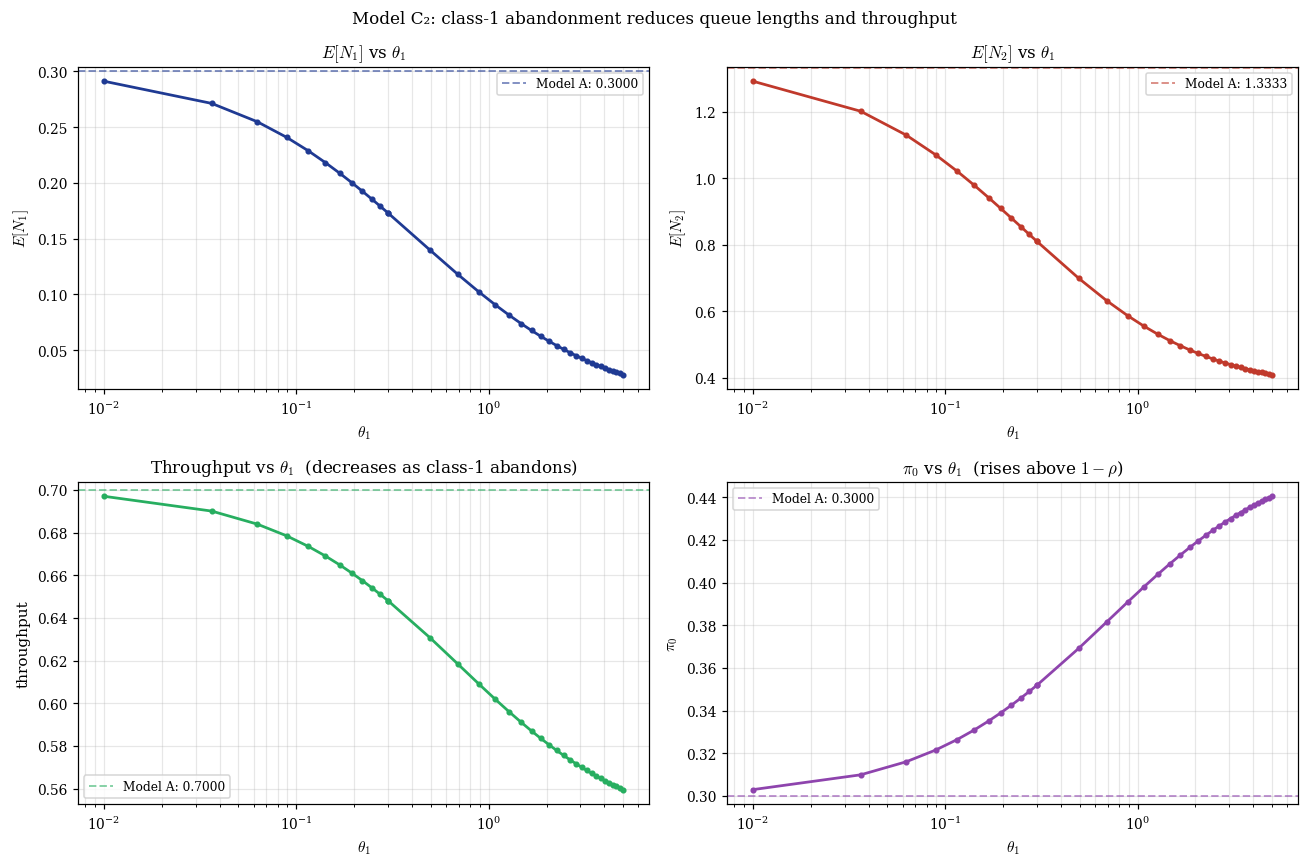

In [5]:
theta1_vals = np.concatenate([np.linspace(0.01, 0.3, 12), np.linspace(0.3, 5.0, 25)])
metrics_C2 = {'pi0': [], 'E_n1': [], 'E_n2': [], 'E_n': [], 'throughput': [], 'aban_rate': []}

for th in theta1_vals:
    p = Params(LAM1, LAM2, MU, theta1=float(th))
    r, d = solve_diag(p)
    metrics_C2['pi0'].append(r['pi_idle'])
    metrics_C2['E_n1'].append(d['E_n1'])
    metrics_C2['E_n2'].append(d['E_n2'])
    metrics_C2['E_n'].append(d['E_n'])
    metrics_C2['throughput'].append(d['throughput'])
    metrics_C2['aban_rate'].append(d['abandonment_rate'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

specs = [
    ('E_n1', r'$E[N_1]$', '#1f3a93', d_A['E_n1'], r'$E[N_1]$ vs $\theta_1$'),
    ('E_n2', r'$E[N_2]$', '#c0392b', d_A['E_n2'], r'$E[N_2]$ vs $\theta_1$'),
    ('throughput', 'throughput', '#27ae60', d_A['throughput'],
     r'Throughput vs $\theta_1$  (decreases as class-1 abandons)'),
    ('pi0', r'$\pi_0$', '#8e44ad', r_A['pi_idle'],
     r'$\pi_0$ vs $\theta_1$  (rises above $1-\rho$)'),
]

for ax, (key, ylabel, color, ref_val, title) in zip(axes.flat, specs):
    ax.semilogx(theta1_vals, metrics_C2[key], 'o-', color=color, ms=3, lw=1.8)
    ax.axhline(ref_val, color=color, ls='--', lw=1.3, alpha=0.55,
               label=f'Model A: {ref_val:.4f}')
    ax.set_xlabel(r'$\theta_1$'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')

fig.suptitle(r'Model C₂: class-1 abandonment reduces queue lengths and throughput', fontsize=11)
fig.tight_layout()


## 5. Cross-model joint distributions $\widetilde{\pi}(n_2, n)$

Heatmaps on $\widetilde{S}$. The white dashed diagonal is $n_2 = n$ (the constraint boundary, i.e. $n_1 = 0$). Jockeying pushes mass toward the diagonal; abandonment drains the upper-left (large $n_1$) toward the diagonal from the right.

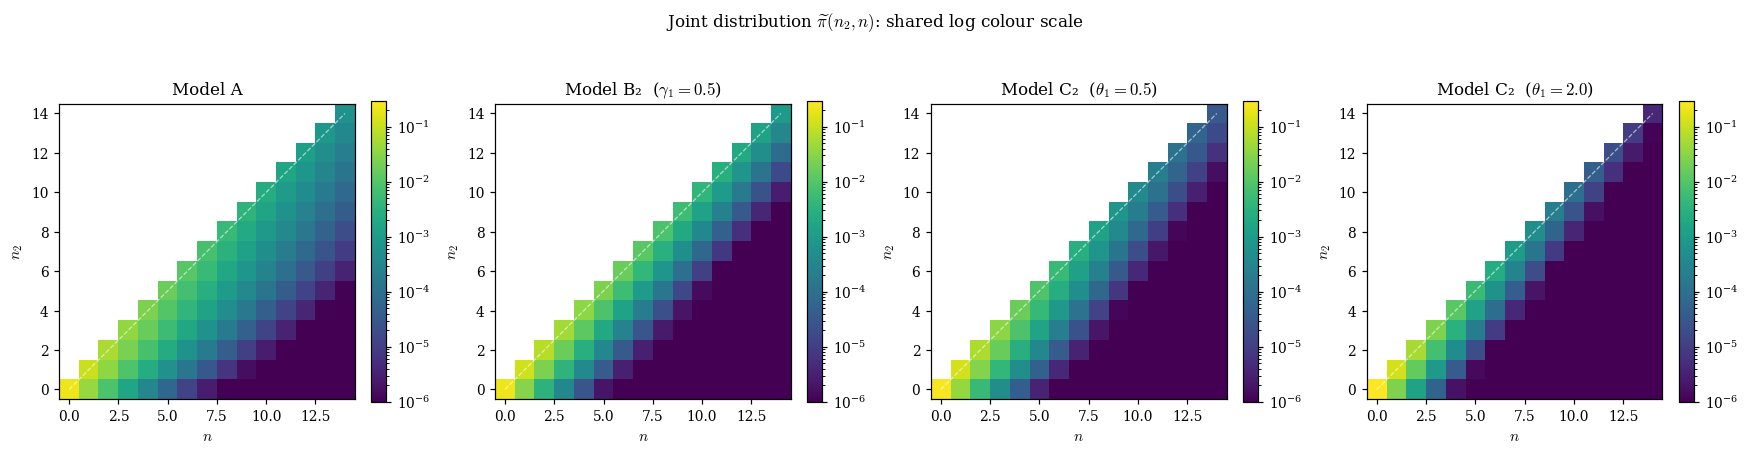

In [6]:
NMAX_PLOT = 14
configs = [
    ('Model A',                    Params(LAM1, LAM2, MU)),
    (r'Model B₂  ($\gamma_1=0.5$)', Params(LAM1, LAM2, MU, gamma1=0.5)),
    (r'Model C₂  ($\theta_1=0.5$)', Params(LAM1, LAM2, MU, theta1=0.5)),
    (r'Model C₂  ($\theta_1=2.0$)', Params(LAM1, LAM2, MU, theta1=2.0)),
]

# common colour scale across all panels
pi_maxes = []
results_list = []
for _, p in configs:
    r, _ = solve_diag(p)
    results_list.append(r)
    pi_maxes.append(r['pi_tilde'][:NMAX_PLOT+1, :NMAX_PLOT+1].max())
vmax_shared = max(pi_maxes)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, (title, _), r in zip(axes, configs, results_list):
    grid = r['pi_tilde'][:NMAX_PLOT+1, :NMAX_PLOT+1].copy()
    n2i, ni = np.indices(grid.shape)
    grid[n2i > ni] = np.nan
    grid = np.where(grid > 0, grid, np.nan)
    im = ax.imshow(grid, origin='lower', cmap='viridis',
                   norm=LogNorm(vmin=1e-6, vmax=vmax_shared))
    ax.plot([0, NMAX_PLOT], [0, NMAX_PLOT], 'w--', lw=0.8, alpha=0.6)
    ax.set_xlabel(r'$n$'); ax.set_ylabel(r'$n_2$')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(r'Joint distribution $\widetilde{\pi}(n_2,n)$: shared log colour scale',
             fontsize=11)
fig.tight_layout()


## 6. Total queue distribution $\mathbb{P}(N=n)$ across models

$\mathbb{P}(N=n) = \sum_{n_2=0}^{n} \widetilde{\pi}(n_2, n)$ for $n \geq 1$, plus $\pi_0$ at $n=0$ (idle). Jockeying leaves this distribution unchanged relative to Model A; abandonment shifts mass toward small $n$.

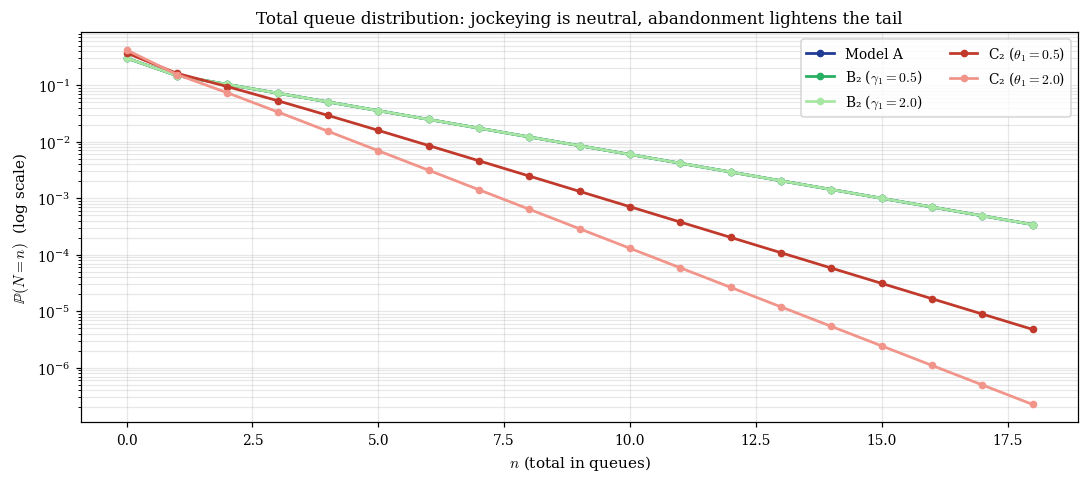

In [7]:
NMAX_DIST = 18
ns = np.arange(NMAX_DIST + 1)

model_specs = [
    ('Model A',                    Params(LAM1, LAM2, MU),              '#1f3a93'),
    (r'B₂ ($\gamma_1=0.5$)',      Params(LAM1, LAM2, MU, gamma1=0.5), '#27ae60'),
    (r'B₂ ($\gamma_1=2.0$)',      Params(LAM1, LAM2, MU, gamma1=2.0), '#a8e6a3'),
    (r'C₂ ($\theta_1=0.5$)',      Params(LAM1, LAM2, MU, theta1=0.5), '#c0392b'),
    (r'C₂ ($\theta_1=2.0$)',      Params(LAM1, LAM2, MU, theta1=2.0), '#f1948a'),
]

fig, ax = plt.subplots(figsize=(10, 4.5))

for label, p, color in model_specs:
    r, _ = solve_diag(p)
    m = marginals_tilde(r['pi_tilde'])
    # P(N=n) for n>=1 is the marginal of total-in-queue n; n=0 is pi_idle
    pn = np.zeros(NMAX_DIST + 1)
    pn[0] = r['pi_idle']
    for n in range(1, NMAX_DIST + 1):
        if n < len(m['pi_n']):
            pn[n] = m['pi_n'][n]
    ax.semilogy(ns, pn, 'o-', color=color, ms=4, lw=1.8, label=label)

ax.set_xlabel(r'$n$ (total in queues)')
ax.set_ylabel(r'$\mathbb{P}(N=n)$  (log scale)')
ax.set_title(r'Total queue distribution: jockeying is neutral, abandonment lightens the tail')
ax.legend(ncol=2); ax.grid(alpha=0.3, which='both')
fig.tight_layout()
